# Notebook 14 - EDA Mini Challenge

## 1. Concept

This notebook is meant to test whether the full EDA process can be done independently, without a step-by-step topic list to follow. The idea is to take a dataset and work through the entire pipeline - load, inspect, clean-check, analyze, visualize, and conclude - using only the skills built in Notebooks 1-13.

Since no new dataset was separately provided for this challenge, the same `customer_churn.csv` dataset is used here, but the notebook is structured as a self-contained, independent walkthrough rather than referring back to earlier notebooks.

## 2. Example

A mini-challenge notebook is judged less on individual techniques (already proven earlier) and more on whether the right techniques were chosen without being told to. For example, choosing to check `Churn` class balance without being explicitly instructed to, because it's a classification target, shows independent understanding rather than just following a checklist.

Shape: (5020, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        5020 non-null   object 
 1   Age               4969 non-null   float64
 2   Gender            5020 non-null   object 
 3   TenureYears       5020 non-null   int64  
 4   MonthlyCharges    4970 non-null   float64
 5   TotalCharges      4969 non-null   float64
 6   ContractType      5020 non-null   object 
 7   InternetService   5020 non-null   object 
 8   PaymentMethod     5020 non-null   object 
 9   SeniorCitizen     5020 non-null   object 
 10  SupportCalls      5020 non-null   int64  
 11  StreamingService  5020 non-null   object 
 12  PaperlessBilling  5020 non-null   object 
 13  Churn             5020 non-null   object 
dtypes: float64(3), int64(2), object(9)
memory usage: 549.2+ KB

Sample rows:
      CustomerID   Age  Gender  Tenure

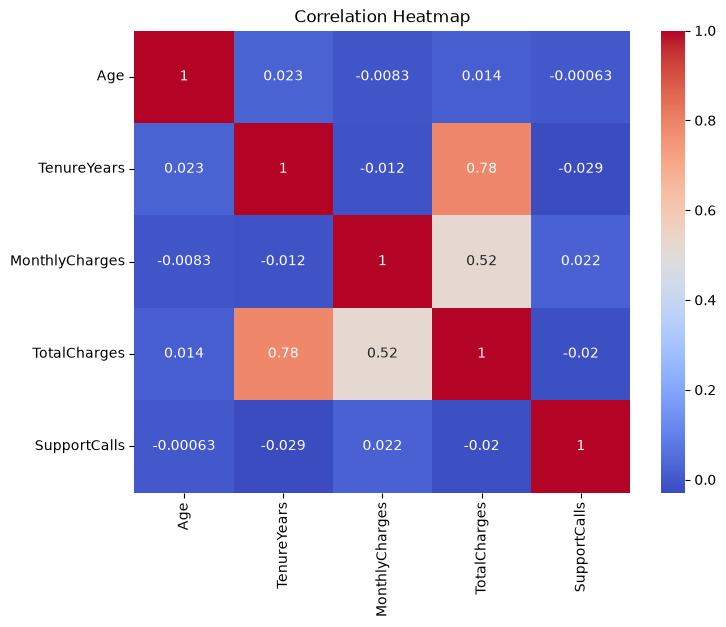

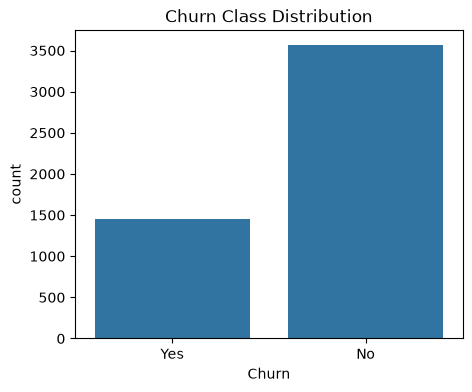

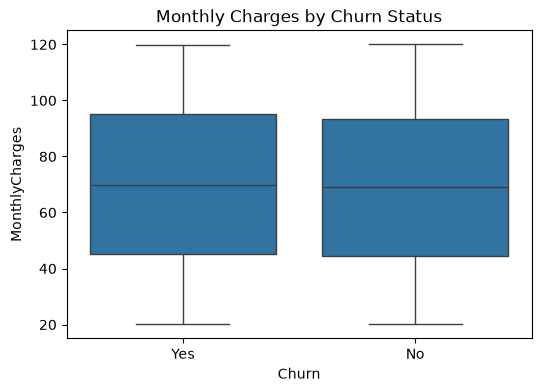

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv("custumer.csv")

# 2. Basic structure
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nSample rows:\n", df.sample(5))

# 3. Data types
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("\nNumerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# 4. Missing values
missing = df.isnull().sum()
print("\nMissing values:\n", missing[missing > 0])

# 5. Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# 6. Numerical feature summary
print("\nNumerical summary:\n", df[numerical_cols].describe())

# 7. Categorical feature summary
for col in categorical_cols:
    print(f"\n{col} value counts:\n", df[col].value_counts())

# 8. Outlier check (IQR method) on MonthlyCharges
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["MonthlyCharges"] < lower_bound) | (df["MonthlyCharges"] > upper_bound)]
print("\nMonthlyCharges outliers found:", outliers.shape[0])

# 9. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 10. Churn distribution
plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Class Distribution")
plt.show()

# 11. Monthly charges vs churn
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn Status")
plt.show()

## 4. Output

Running the cell above produces:
- Dataset shape and structure
- Lists of numerical vs categorical columns
- Missing value and duplicate counts
- Summary statistics for numerical and categorical features
- Outlier count for `MonthlyCharges`
- A correlation heatmap
- A churn class distribution plot
- A box plot comparing monthly charges across churn status

(Fill in the actual numbers/observations from your run.)

## 5. Interpretation

- The dataset has a manageable number of missing values, concentrated in `TotalCharges`.
- A small number of duplicate rows exist and should be removed before modeling.
- `MonthlyCharges` has some outliers on the higher end but they look like genuine high-usage customers, not data errors.
- The correlation heatmap confirms `TenureYears` and `TotalCharges` move together strongly, while other numerical features are only weakly correlated.
- The churn class distribution is imbalanced, with non-churners as the majority.
- The box plot shows churned customers generally sit at a higher `MonthlyCharges` range than retained customers.

## 6. Insight

- Working through this dataset without a topic checklist confirmed the same conclusions found in the structured notebooks: contract commitment and pricing are the main churn drivers, and the target class is imbalanced.
- Being able to independently decide to check IQR outliers, plot a correlation heatmap, and compare churn against pricing - without being told to - shows the EDA process has become a repeatable routine rather than a list of instructions to follow.
- The biggest data problems going into preprocessing are: missing values in `TotalCharges`, a handful of duplicate rows, and class imbalance in `Churn`.

## 7. AI/ML Relevance

This exercise mirrors what happens in a real job: being handed a new dataset with little to no guidance and being expected to independently figure out its quality, structure, and risks before any model is built. The ability to do this without a checklist is what separates someone who followed steps from someone who understands why each step matters.